# EDA-1 — Target Characterisation (Y)

`total_points` is the target variable for all FPL lens studies. Before any
correlation analysis runs, we need to understand its shape, variance structure,
and sensitivity to fixture type and population filter.

This notebook answers eight questions. The answers are constraints, not verdicts:
they determine which analytical methods are valid, which populations are in scope,
and what claims the study layer is permitted to make.

Gate decisions produced here are inherited by every downstream lens study (EDA-2+).
They are not revisited per study.

## Analytical Context

### Panel data structure

The dataset is a player × gameweek panel. Every player appears once per GW they
had a fixture. Total Y variance has two components:

- **Between-player variance**: differences in average returns across players
  (player quality sorting)
- **Within-player variance**: differences in a single player's returns across GWs
  (event-level variation — form, fixture, matchup)

This decomposition (Q1.8) governs what downstream studies can claim. A signal
that correlates with Y may be identifying *which players are good* (between-player
dominant) or *when a player will score above their baseline* (within-player
dominant). These are different claims, useful for different decisions.

### Decision types

- **Transfer decisions** — own a player across multiple GWs. Between-player signal
  is useful. Timing precision matters less.
- **Captaincy decisions** — double one player's return for one GW. Within-player
  elevation above baseline is what matters. Haul likelihood (right-tail events)
  is directly relevant.
- **Chip decisions** — depend on both, at scale.

### What this means for method choice

If Y is right-skewed and haul-heavy, Pearson correlation is distorted by outliers.
Spearman rank correlation is robust to this. Q1.1 confirms whether Spearman is
justified — this propagates to every correlation calculation in the project.

## Scope

- **Study range:** GW 6 to latest completed GW (derived dynamically from `finished` flag in fixtures)
- **Inputs:** State table (`build_player_gameweek_state`)
- **Out of scope:** Signal-target correlations (EDA-2+), filter removal rates (EDA-3), cross-position comparability (EDA-3/EDA-3)

**Gate decisions produced here:**

| Decision | Question | Applies to |
|---|---|---|
| Spearman vs Pearson | Q1.1 | All correlation calculations |
| DGW treatment | Q1.6 | All lens studies |
| Timing signal vs quality proxy framing | Q1.8 | Study layer claims per position |

**Descriptive profiles produced here (not gate decisions):**

| Profile | Question | Used by |
|---|---|---|
| Y shape per position | Q1.2 | EDA-3/EDA-3 as baseline reference |

## Setup

Imports, constants, and display options. Helper functions are in
`_target_distribution_helpers.py` — the notebook calls them; it does not implement them.

In [101]:
from pathlib import Path
import sqlite3
import pandas as pd
import numpy as np
from IPython.display import display

from dal.state.player_gameweek_state import build_player_gameweek_state
from research.eda.notebooks._target_distribution_helpers import (
    analyze_by_group,
    analyze_dgw_vs_sgw,
    analyze_tail_frequency,
)

DB_PATH = Path.home() / ".fpl" / "fpl.db"
STUDY_GW_MIN = 6
POSITION_MAP = {1: "GK", 2: "DEF", 3: "MID", 4: "FWD"}

# Derive upper bound dynamically: all GWs where every fixture is finished
fixtures_df = pd.read_sql("SELECT event, finished FROM fixtures", sqlite3.connect(DB_PATH))
finished_gws = (
    fixtures_df.groupby('event')['finished']
    .all()
    .loc[lambda s: s]
    .index
)
STUDY_GW_MAX = int(finished_gws.max())
print(f"Study range: GW {STUDY_GW_MIN} – GW {STUDY_GW_MAX} (derived from finished fixtures)")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:.2f}".format)

## Load and Population Definition

Build the state table, filter to the study range (GW 6 – latest completed GW), assign GW blocks,
and define the two analytical populations. The upper bound is derived dynamically from the
`finished` flag in the fixtures table — all completed GWs are included automatically.

### Populations

- `state_all_fixture`: every player whose team had a fixture this GW, regardless of
  participation. BGW scaffold rows (`fixture_count == 0`) are excluded — this is a data
  property, not an analytical choice. Used only in Q1.0 to establish the mixture claim.

- `state_primary`: players with minutes ≥ 60. This is not a signal filter — it is the
  exposure threshold that makes Y meaningful. Justified in Q1.0, used for all subsequent
  analysis (Q1.1–Q1.8).

In [102]:
state_all = build_player_gameweek_state()

# Filter to study range (upper bound derived dynamically in setup)
state = state_all[state_all["gw"].between(STUDY_GW_MIN, STUDY_GW_MAX)].copy()

# GW blocks: divide completed range into thirds
gw_range = STUDY_GW_MAX - STUDY_GW_MIN + 1
early_end = STUDY_GW_MIN + gw_range // 3 - 1
mid_end   = STUDY_GW_MIN + 2 * (gw_range // 3) - 1

def assign_gw_block(gw):
    if gw <= early_end:
        return "early"
    elif gw <= mid_end:
        return "mid"
    else:
        return "late"

state["gw_block"] = state["gw"].apply(assign_gw_block)
print(f"GW blocks: early=GW{STUDY_GW_MIN}–{early_end}, mid=GW{early_end+1}–{mid_end}, late=GW{mid_end+1}–{STUDY_GW_MAX}")

# Define analytical populations
state_all_fixture = state[state['fixture_count'] > 0]   # has fixture, any participation level
state_primary     = state[state['minutes'] >= 60]        # primary analytical population

print(f"\nState rows in study range (GW {STUDY_GW_MIN}-{STUDY_GW_MAX}): {len(state):,}")
print(f"\nPopulation sizes:")
print(f"  state_all_fixture : {len(state_all_fixture):>7,}  (fixture_count > 0)")
print(f"  state_primary     : {len(state_primary):>7,}  (minutes >= 60)")

print(f"\nFirst few rows:")
display(state.head())

State rows in study range (GW 6-34): 24,070

Population sizes:
  state_all_fixture :  22,399  (fixture_count > 0)
  state_primary     :   5,879  (minutes >= 60)

First few rows:


,player_id,gw,player_name,position_code,team_id,purchase_price,ownership_count,transfers_in,total_points,minutes,goals_scored,assists,clean_sheets,yellow_cards,red_cards,saves,bonus,bps,goals_conceded,xg,xa,xgi,xgc,fdr_avg,fdr_min,fdr_max,transfers_balance,fixture_count,is_bgw,is_dgw,home_count,away_count,was_home,starts,penalties_saved,penalties_missed,own_goals,influence,creativity,threat,ict_index,in_dreamteam,transfers_out,points_roll3,points_roll5,minutes_roll3,minutes_roll5,xg_roll3,xg_roll5,xa_roll3,xa_roll5,xgi_roll3,xgi_roll5,goals_scored_roll3,goals_scored_roll5,assists_roll3,assists_roll5,fixture_context,minutes_trend,gw_block
5,1,6,Raya,1,1,5.60,3029654,357846,2,90,0,0,0,0,0,2,0,11,1,0.00,0.01,0.01,0.61,3.00,3.00,3.00,227251,1,False,False,0,1,False,1,0,0,0,15.80,0.00,0.00,1.60,0,130595,3.33,5.20,90.00,90.00,0.00,0.00,0.01,0.01,0.01,0.01,0.00,0.00,0.00,0.00,SGW,stable,early
6,1,7,Raya,1,1,5.60,3297838,287510,6,90,0,0,1,0,0,0,0,20,0,0.00,0.00,0.00,0.49,2.00,2.00,2.00,212315,1,False,False,1,0,True,1,0,0,0,3.20,0.00,0.00,0.30,0,75195,3.33,3.60,90.00,90.00,0.00,0.00,0.01,0.01,0.01,0.01,0.00,0.00,0.00,0.00,SGW,stable,early
7,1,8,Raya,1,1,5.70,3447590,208192,6,90,0,0,1,0,0,0,0,21,0,0.00,0.00,0.00,0.44,3.00,3.00,3.00,120482,1,False,False,0,1,False,1,0,0,0,4.60,0.00,0.00,0.50,0,87710,3.33,3.60,90.00,90.00,0.00,0.00,0.01,0.01,0.01,0.01,0.00,0.00,0.00,0.00,SGW,stable,early
8,1,9,Raya,1,1,5.70,3546345,131150,6,90,0,0,1,0,0,1,0,25,0,0.00,0.00,0.00,0.47,3.00,3.00,3.00,81905,1,False,False,1,0,True,1,0,0,0,15.00,0.10,0.00,1.50,0,49245,4.67,4.40,90.00,90.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,SGW,stable,early
9,1,10,Raya,1,1,5.80,3816996,267422,6,90,0,0,1,0,0,0,0,20,0,0.00,0.00,0.00,0.42,2.00,2.00,2.00,227648,1,False,False,0,1,False,1,0,0,0,2.80,0.10,0.00,0.30,0,39774,6.00,4.40,90.00,90.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,SGW,stable,early


## Result Recording

Track findings and gate decisions across all questions.

In [103]:
results: dict[str, dict[str, object]] = {}

def record_result(question: str, result: str, **details: object) -> None:
    results[question] = {"result": result, **details}

def print_header(title: str) -> None:
    print(f"\n{'=' * 88}")
    print(title)
    print(f"{'=' * 88}")

record_result(
    "META",
    "INFO",
    n_state_rows=len(state),
    n_all_fixture=len(state_all_fixture),
    n_primary=len(state_primary),
    gw_range=(STUDY_GW_MIN, STUDY_GW_MAX),
    db_path=str(DB_PATH),
)

## Q1.0 — Raw Y Before Any Filter

**Question:** What does `total_points` look like before any exposure criterion is applied, and does this justify the analytical population choice?

**Why this matters:** The goal of population definition is to ensure Y is **comparable across observations** — not to clean the data, but to define the unit of study. `state_primary` is not "the data with minutes >= 60 applied." It is the set of **player-gameweeks where a player had sufficient exposure for their score to reflect performance**. The minutes threshold is the operationalisation of that criterion, not the criterion itself.

Without this restriction, `total_points` is generated by heterogeneous processes:

- `state_all_fixture` mixes non-participating rows (0 minutes) with full-match performances — the outcome distribution is dominated by non-participation, not performance
- `minutes > 0` removes non-participation but still mixes low-exposure appearances (1–30 minute substitutions) with full-match outcomes, producing heterogeneous variance and compressed score mass at 1–2 pts — these observations are not relevant to performance

**On the 60-minute threshold:**

60 minutes is the best available proxy for sufficient exposure in this dataset. It is not claimed to be optimal or theoretically derived — it is the instrument through which the performance-relevance criterion is operationalised. Two considerations support it: statistically, it approximates the minimum exposure window for goals, assists, bonus, and clean sheet contributions to accumulate meaningfully; practically, it aligns with FPL scoring rules and standard football analytics convention.

The honest caveat is not that 60 is arbitrary — it is that **whether 60 minutes correctly classifies every observation as performance-relevant is an empirical question**. A player subbed off at 61 minutes injured may not meet the spirit of the criterion; a player who played 59 dominant minutes may. EDA-3 tests whether analytical conclusions are stable across alternative thresholds (45, 75 minutes).

**Expected result:** High zero mass (>40%) in `state_all_fixture`, materially lower in `state_primary`. Mean and skew shift substantially between populations, confirming the need for the exposure criterion.

In [104]:
print_header("Q1.0 — Raw Y Before Any Filter")

y_raw     = state_all_fixture['total_points'].dropna()
y_primary = state_primary['total_points'].dropna()

print(f"state_all_fixture records: {len(state_all_fixture):,}")
print(f"state_primary records:     {len(state_primary):,}")

print(f"\nScore mass breakdown:")
print(f"  {'':20}  {'state_all_fixture':>18}  {'state_primary':>13}")
for threshold in [1, 2]:
    pct_raw     = (y_raw <= threshold).mean() * 100
    pct_primary = (y_primary <= threshold).mean() * 100
    print(f"  {'<= ' + str(threshold) + ' pts':<20}  {pct_raw:>17.1f}%  {pct_primary:>12.1f}%")

neg_raw     = (y_raw < 0).mean() * 100
neg_primary = (y_primary < 0).mean() * 100
zero_raw    = (y_raw == 0).mean() * 100
zero_primary = (y_primary == 0).mean() * 100

print(f"  {'negative (< 0)':<20}  {neg_raw:>17.1f}%  {neg_primary:>12.1f}%")
print(f"  {'strict zero (== 0)':<20}  {zero_raw:>17.1f}%  {zero_primary:>12.1f}%")
print(f"  {'zero-or-below (<= 0)':<20}  {(y_raw <= 0).mean()*100:>17.1f}%  {(y_primary <= 0).mean()*100:>12.1f}%")

print(f"\nDistribution comparison:")
print(f"  {'metric':<10}  {'state_all_fixture':>18}  {'state_primary':>13}")
print(f"  {'mean':<10}  {y_raw.mean():>18.2f}  {y_primary.mean():>13.2f}")
print(f"  {'median':<10}  {y_raw.median():>18.2f}  {y_primary.median():>13.2f}")
print(f"  {'skew':<10}  {y_raw.skew():>18.2f}  {y_primary.skew():>13.2f}")

record_result(
    "Q1.0",
    "CONSTRAINT",
    finding=(
        f"Without an exposure criterion, Y reflects heterogeneous processes — "
        f"non-participation and low-exposure cameos produce observations that are "
        f"not relevant to performance. "
        f"state_all_fixture: {zero_raw:.1f}% strict zero mass, {neg_raw:.1f}% negative. "
        f"state_primary: {zero_primary:.1f}% strict zero mass, {neg_primary:.1f}% negative."
    ),
    implication=(
        "state_primary is defined as player-gameweeks where a player had sufficient "
        "exposure for their score to reflect performance. The minutes >= 60 threshold "
        "is the operationalisation of this criterion, not the criterion itself."
    ),
    constraint=(
        "All EDA-1 through EDA-3 analysis uses state_primary (minutes >= 60). "
        "Whether this threshold correctly classifies every observation as "
        "performance-relevant is an empirical question tested in EDA-3."
    ),
)


Q1.0 — Raw Y Before Any Filter
state_all_fixture records: 22,399
state_primary records:     5,879

Score mass breakdown:
                         state_all_fixture  state_primary
  <= 1 pts                           77.2%          17.3%
  <= 2 pts                           85.6%          49.1%
  negative (< 0)                      0.3%           0.5%
  strict zero (== 0)                 63.3%           2.9%
  zero-or-below (<= 0)               63.5%           3.3%

Distribution comparison:
  metric       state_all_fixture  state_primary
  mean                      1.17           3.87
  median                    0.00           3.00
  skew                      3.02           1.58


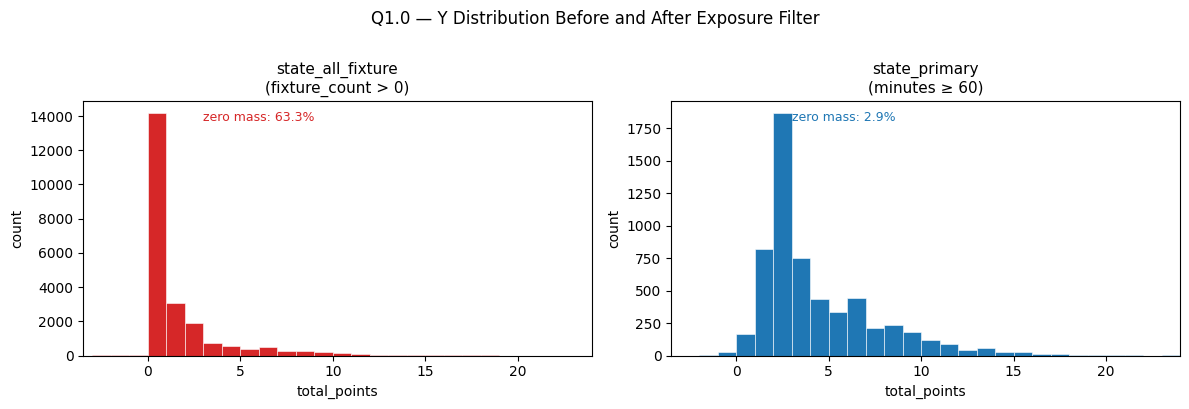

In [105]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

x_max = max(y_raw.max(), y_primary.max()) + 1
bins = range(int(y_raw.min()), int(x_max) + 1)

ax0, ax1 = axes

ax0.hist(y_raw, bins=bins, color="#d62728", edgecolor="white", linewidth=0.4)
ax0.set_title("state_all_fixture\n(fixture_count > 0)", fontsize=11)
ax0.set_xlabel("total_points")
ax0.set_ylabel("count")
ax0.set_xlim(y_raw.min() - 0.5, x_max)
ax0.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax0.annotate(
    f"zero mass: {zero_raw:.1f}%",
    xy=(0, ax0.get_ylim()[1]),
    xytext=(3, ax0.get_ylim()[1] * 0.92),
    fontsize=9, color="#d62728",
)

ax1.hist(y_primary, bins=bins, color="#1f77b4", edgecolor="white", linewidth=0.4)
ax1.set_title("state_primary\n(minutes ≥ 60)", fontsize=11)
ax1.set_xlabel("total_points")
ax1.set_ylabel("count")
ax1.set_xlim(y_raw.min() - 0.5, x_max)
ax1.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax1.annotate(
    f"zero mass: {zero_primary:.1f}%",
    xy=(0, ax1.get_ylim()[1]),
    xytext=(3, ax1.get_ylim()[1] * 0.92),
    fontsize=9, color="#1f77b4",
)

fig.suptitle("Q1.0 — Y Distribution Before and After Exposure Filter", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Q1.1 — Overall Y Distribution

**Question:** What is the distributional shape of `total_points` in `state_primary`, and does it support rank-based correlation methods?

**Why this matters:** Right-skew and a heavy upper tail indicate that magnitude-sensitive statistics (e.g. Pearson correlation) may be distorted by extreme haul scores. Rank-based methods (Spearman) are preferred for robustness in this setting. This justification is distributional only — validation of the correlation method occurs in EDA-2 where real signal–target relationships are tested.

**Expected result:** Mean > median, skew > 1, elevated kurtosis, heavy right tail (p99 in 20–25 pt range).

In [106]:
print_header("Q1.1 — Overall Y Distribution")

mean_y_primary   = y_primary.mean()
median_y_primary = y_primary.median()
std_y_primary    = y_primary.std()
skew_y_primary   = y_primary.skew()
kurt_y_primary   = y_primary.kurtosis()
min_y_primary    = y_primary.min()
max_y_primary    = y_primary.max()
p90_y_primary    = y_primary.quantile(0.90)
p95_y_primary    = y_primary.quantile(0.95)
p99_y_primary    = y_primary.quantile(0.99)

tail_10_points = (y_primary > 10).mean() * 100
tail_15_points = (y_primary > 15).mean() * 100
tail_20_points = (y_primary > 20).mean() * 100

print(f"\nDistribution Statistics (state_primary):")
print(f"  count:    {len(y_primary):,}")
print(f"  mean:     {mean_y_primary:.2f}")
print(f"  median:   {median_y_primary:.2f}")
print(f"  std:      {std_y_primary:.2f}")
print(f"  skew:     {skew_y_primary:.2f}")
print(f"  kurtosis: {kurt_y_primary:.2f}")
print(f"  min:      {min_y_primary:.0f}   max: {max_y_primary:.0f}")

print(f"\nTail Quantiles:")
print(f"  p90: {p90_y_primary:.1f} pts")
print(f"  p95: {p95_y_primary:.1f} pts")
print(f"  p99: {p99_y_primary:.1f} pts")

print(f"\nTail Mass (% records exceeding threshold):")
print(f"  > 10 pts: {tail_10_points:.1f}%")
print(f"  > 15 pts: {tail_15_points:.1f}%")
print(f"  > 20 pts: {tail_20_points:.1f}%")

print(f"\nInterpretation:")
print(f"  Right-skew ({skew_y_primary:.2f}) and heavy upper tail (p99 = {p99_y_primary:.0f} pts) indicate")
print(f"  that magnitude-sensitive statistics (Pearson) may be influenced by extreme haul values.")
print(f"  Rank-based methods (Spearman) are therefore preferred for robustness.")
print(f"  Final validation of correlation method is performed in EDA-2 using actual signal–target relationships.")

record_result(
    "Q1.1",
    "STRONG_EVIDENCE",
    mean=round(mean_y_primary, 2),
    median=float(median_y_primary),
    std=round(std_y_primary, 2),
    skew=round(skew_y_primary, 2),
    kurtosis=round(kurt_y_primary, 2),
    min=float(min_y_primary),
    max=float(max_y_primary),
    p90=float(p90_y_primary),
    p95=float(p95_y_primary),
    p99=float(p99_y_primary),
    note="Heavy right tail → Spearman preferred; validated in EDA-2",
)

print(f"\n→ Result: STRONG_EVIDENCE — Spearman preferred, validated in EDA-2")


Q1.1 — Overall Y Distribution

Distribution Statistics (state_primary):
  count:    5,879
  mean:     3.87
  median:   3.00
  std:      3.22
  skew:     1.58
  kurtosis: 2.80
  min:      -2   max: 23

Tail Quantiles:
  p90: 8.0 pts
  p95: 10.0 pts
  p99: 15.0 pts

Tail Mass (% records exceeding threshold):
  > 10 pts: 4.8%
  > 15 pts: 0.7%
  > 20 pts: 0.1%

Interpretation:
  Right-skew (1.58) and heavy upper tail (p99 = 15 pts) indicate
  that magnitude-sensitive statistics (Pearson) may be influenced by extreme haul values.
  Rank-based methods (Spearman) are therefore preferred for robustness.
  Final validation of correlation method is performed in EDA-2 using actual signal–target relationships.

→ Result: STRONG_EVIDENCE — Spearman preferred, validated in EDA-2


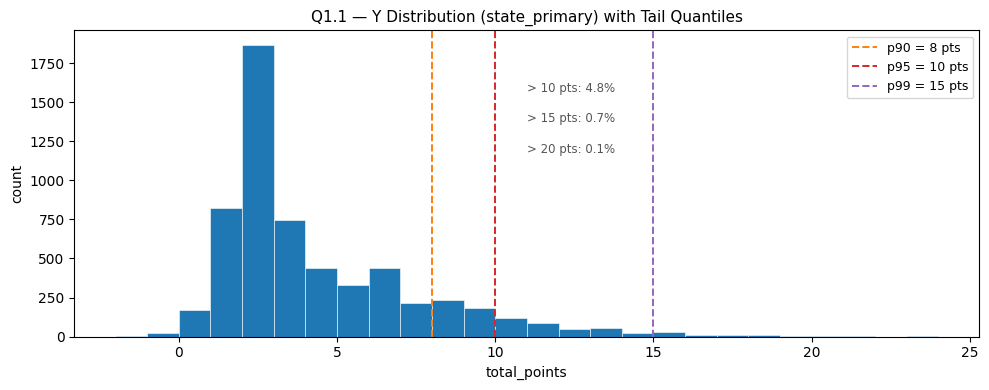

In [107]:
fig, ax = plt.subplots(figsize=(10, 4))

bins = range(int(y_primary.min()), int(y_primary.max()) + 2)
ax.hist(y_primary, bins=bins, color="#1f77b4", edgecolor="white", linewidth=0.4)

quantiles = {"p90": p90_y_primary, "p95": p95_y_primary, "p99": p99_y_primary}
colours   = {"p90": "#ff7f0e", "p95": "#d62728", "p99": "#9467bd"}

for label, val in quantiles.items():
    ax.axvline(val, color=colours[label], linestyle="--", linewidth=1.4, label=f"{label} = {val:.0f} pts")

y_top = ax.get_ylim()[1]
ax.annotate(f"> 10 pts: {tail_10_points:.1f}%", xy=(11, y_top * 0.80), fontsize=8.5, color="#555")
ax.annotate(f"> 15 pts: {tail_15_points:.1f}%", xy=(11, y_top * 0.70), fontsize=8.5, color="#555")
ax.annotate(f"> 20 pts: {tail_20_points:.1f}%", xy=(11, y_top * 0.60), fontsize=8.5, color="#555")

ax.set_title("Q1.1 — Y Distribution (state_primary) with Tail Quantiles", fontsize=11)
ax.set_xlabel("total_points")
ax.set_ylabel("count")
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Q1.2 — Y Distribution by Position

**Question:** What is the shape of `total_points` within each position?

**Why this matters:** Position stratification is justified by decision structure, not distributional distance. Transfer and captaincy decisions are made within positions — a DEF competes against other DEFs for a squad slot, not against MIDs or FWDs. A signal that predicts DEF returns only needs to work within that stratum to be useful. Stratification is therefore fixed before this question runs.

What Q1.2 does is profile the geometry of Y within each stratum — mean, spread, and tail behaviour — so downstream studies have a documented baseline. The GK position is structurally distinct from outfield (clean sheet as the primary ceiling driver, no goal contribution). DEF, MID, and FWD are closer to each other in bulk distribution but remain separate strata by decision logic.

**Expected result:** All positions right-skewed. GK lower mean and compressed tail relative to outfield. DEF, MID, FWD similar in bulk distribution with modest tail differences.

In [108]:
print_header("Q1.2 — Y Distribution by Position")

state_primary_copy = state_primary.copy()
state_primary_copy['position_code'] = state_primary_copy['position_code'].map(POSITION_MAP)
pos_stats = analyze_by_group(state_primary_copy, 'position_code', 'total_points')

print("\nDistribution Statistics by Position (state_primary):")
display(pos_stats[['position_code', 'count', 'mean', 'median', 'std', 'p90', 'p99', 'skew']])

print("\nKey Observations:")
print("- GK has lowest mean and compressed upper tail")
print("- FWD exhibits highest upper-tail mass (p90/p99 inflation)")
print("- MID and DEF sit between GK and FWD in both mean and tail behavior")
print("- All positions remain right-skewed, but with different tail intensities")

record_result(
    "Q1.2",
    "INFO",
    positions_analyzed=['GK', 'DEF', 'MID', 'FWD'],
    note="Position Y profiles are structurally distinct. Cross-position rho comparability assessed in EDA-3/EDA-3.",
)


Q1.2 — Y Distribution by Position

Distribution Statistics by Position (state_primary):


,position_code,count,mean,median,std,p90,p99,skew
0,DEF,2269,3.75,3.00,3.33,8.00,15.00,1.38
1,FWD,573,4.14,2.00,3.49,9.00,16.00,1.58
2,GK,567,3.39,2.00,2.75,7.00,11.00,1.35
3,MID,2470,4.03,3.00,3.13,9.00,15.00,1.81



Key Observations:
- GK has lowest mean and compressed upper tail
- FWD exhibits highest upper-tail mass (p90/p99 inflation)
- MID and DEF sit between GK and FWD in both mean and tail behavior
- All positions remain right-skewed, but with different tail intensities


## Q1.3 — Tail Frequency (Haul Analysis)

**Question:** How heavy is the right tail of Y, and where does it sit by position?

**Why this matters:** Haul scores are rare but concentrate a disproportionate share of outcome mass.
Documenting their frequency and positional distribution provides the structural baseline for downstream
decisions about tail treatment. Whether the tail *distorts correlation estimates* is assessed in EDA-3,
not here.

**Expected result:** Hauls (>15 pts) rare across all positions. Tail mass higher in FWD/MID than GK/DEF.

In [109]:
print_header("Q1.3 — Tail Frequency (Haul Analysis)")

thresholds = [8, 10, 12, 15, 20]
tail_freq = analyze_tail_frequency(
    state_primary,
    'total_points',
    thresholds,
    position_map=POSITION_MAP,
)

print("\nTail Frequency by Position (state_primary, % exceeding threshold):")
display(tail_freq)

fwd_haul_pct = tail_freq.loc[tail_freq['threshold'] == 15, 'FWD'].values[0]
gk_haul_pct  = tail_freq.loc[tail_freq['threshold'] == 15, 'GK'].values[0]

print("\nKey Observations:")
print(f"- Hauls (>15 pts) are rare events across all positions")
print(f"- FWD haul frequency: {fwd_haul_pct:.1f}%")
print(f"- GK haul frequency:  {gk_haul_pct:.1f}%")
print("- Tail mass is concentrated in attacking positions (FWD, MID)")
print("- GK and DEF exhibit compressed upper tails relative to attackers")

record_result(
    "Q1.3",
    "INFO",
    haul_threshold=15,
    fwd_haul_frequency=fwd_haul_pct,
    gk_haul_frequency=gk_haul_pct,
    note="Tail influence on correlation stability assessed in EDA-3.",
)


Q1.3 — Tail Frequency (Haul Analysis)

Tail Frequency by Position (state_primary, % exceeding threshold):


,threshold,DEF,FWD,GK,MID
8,8.00,8.99,12.57,6.70,10.93
10,10.00,4.50,7.16,1.59,5.22
12,12.00,2.07,5.24,0.88,2.67
15,15.00,0.71,1.22,0.18,0.73
20,20.00,0.13,0.00,0.00,0.00



Key Observations:
- Hauls (>15 pts) are rare events across all positions
- FWD haul frequency: 1.2%
- GK haul frequency:  0.2%
- Tail mass is concentrated in attacking positions (FWD, MID)
- GK and DEF exhibit compressed upper tails relative to attackers


## Q1.4 — Zero and Low-Score Mass

**Question:** What is the residual low-score distribution after the activity filter (`minutes >= 60`) is applied?

**Why this matters:** Documenting residual zero and low-score mass characterises what Y looks like at the bottom of the distribution in the analytical population. High residual zero mass would indicate the filter leaves non-participating records in place — but filter adequacy is formally assessed in EDA-3. This question is descriptive only.

**Expected result:** Low zero mass across outfield positions. GK may retain higher low-score mass due to clean-sheet dependence.

In [110]:
print_header("Q1.4 — Zero and Low-Score Mass")

POSITION_LABELS = {1: "GK", 2: "DEF", 3: "MID", 4: "FWD"}

thresholds = [0, 1, 2]
rows = []
for pos_code, pos_label in POSITION_LABELS.items():
    y_pos = state_primary[state_primary['position_code'] == pos_code]['total_points'].dropna()
    row = {'position': pos_label, 'n': len(y_pos)}
    for t in thresholds:
        row[f'<={t}_pts_pct'] = round((y_pos <= t).mean() * 100, 1)
    rows.append(row)

zero_mass_df = pd.DataFrame(rows)
print("\nLow-score mass (state_primary):")
display(zero_mass_df)

print("\nKey Observations:")
print("- Zero mass (<=0 pts) is low across all positions, consistent with the minutes >= 60 filter")
print("- GK low-score mass (<=1 pt) is elevated relative to outfield — reflects clean-sheet dependence")
print("- DEF <=1 pt mass is higher than MID/FWD, consistent with defensive structure")

record_result(
    "Q1.4",
    "INFO",
    zero_mass_by_position={
        row['position']: row['<=0_pts_pct'] for row in rows
    },
    note="Filter adequacy assessed in EDA-3.",
)

print(f"\n→ Result: INFO — descriptive profile only")


Q1.4 — Zero and Low-Score Mass

Low-score mass (state_primary):


,position,n,<=0_pts_pct,<=1_pts_pct,<=2_pts_pct
0,GK,567,2.30,23.10,55.90
1,DEF,2269,7.40,29.80,49.80
2,MID,2470,0.50,7.40,43.70
3,FWD,573,0.70,4.50,62.30



Key Observations:
- Zero mass (<=0 pts) is low across all positions, consistent with the minutes >= 60 filter
- GK low-score mass (<=1 pt) is elevated relative to outfield — reflects clean-sheet dependence
- DEF <=1 pt mass is higher than MID/FWD, consistent with defensive structure

→ Result: INFO — descriptive profile only


## Q1.5 — GW Blocks (Temporal Stability)

**Question:** Is Y distribution stable across GW blocks (early GW 6–14, mid GW 15–24, late GW 25–34)?

**Why this matters:** Late-season Y may drift due to injuries, form changes, or fixture congestion. If the distribution shifts materially from early to late, the decision to pool all blocks for analysis needs justification.

The KS test is applied as a nonparametric comparison of empirical distributions. Because sample sizes are large, the test has high power and may detect statistically significant differences even when the practical magnitude is small. Additionally, since `total_points` is discrete, the theoretical KS p-values are not exact and can be conservative in the presence of ties. Interpretation therefore focuses on the KS statistic and quantile deltas (median, P90) to assess whether any detected difference is practically meaningful.

**Expected result:** Early and late blocks have similar distributional shape. Any drift is small in practical magnitude.

In [111]:
from scipy.stats import ks_2samp

print_header("Q1.5 — GW Blocks (Temporal Stability)")

block_stats = analyze_by_group(state_primary, 'gw_block', 'total_points')
print("\nGW Block Statistics (state_primary):")
display(block_stats[['gw_block', 'count', 'mean', 'median', 'std', 'variance', 'skew']])

early_block = state_primary[state_primary['gw_block'] == 'early']['total_points'].dropna()
late_block  = state_primary[state_primary['gw_block'] == 'late']['total_points'].dropna()

early_mean   = early_block.mean()
late_mean    = late_block.mean()
early_median = early_block.median()
late_median  = late_block.median()
early_p90    = early_block.quantile(0.90)
late_p90     = late_block.quantile(0.90)

median_diff = late_median - early_median
p90_diff    = late_p90 - early_p90

ks_stat, ks_pval = ks_2samp(early_block, late_block)

print(f"\nKS Test (early vs late block):")
print(f"  KS statistic: {ks_stat:.4f}")
print(f"  p-value:      {ks_pval:.4f}")

print(f"\nQuantile Deltas (late - early):")
print(f"  median_diff: {median_diff:+.2f} pts")
print(f"  p90_diff:    {p90_diff:+.2f} pts")

print(f"\nInterpretation:")
print(f"  KS indicates {'statistically detectable difference' if ks_pval < 0.05 else 'no statistically detectable difference'} between early and late blocks.")
print(f"  Median shift: {median_diff:+.2f} pts — {'practically negligible' if abs(median_diff) < 0.5 else 'potentially meaningful'}.")
print(f"  P90 shift:    {p90_diff:+.2f} pts — {'practically negligible' if abs(p90_diff) < 1.0 else 'potentially meaningful'}.")

drift_detected = ks_pval < 0.05 and (abs(median_diff) >= 0.5 or abs(p90_diff) >= 1.0)
result = "DRIFT_DETECTED" if drift_detected else "STABLE"

record_result(
    "Q1.5",
    result,
    ks_stat=round(ks_stat, 4),
    ks_pval=round(ks_pval, 4),
    early_mean=round(early_mean, 2),
    late_mean=round(late_mean, 2),
    median_diff=round(median_diff, 2),
    p90_diff=round(p90_diff, 2),
)

print(f"\n→ Result: {result}")


Q1.5 — GW Blocks (Temporal Stability)

GW Block Statistics (state_primary):


,gw_block,count,mean,median,std,variance,skew
0,early,1841,3.78,2.00,3.27,10.67,1.71
1,late,1970,3.97,3.00,3.26,10.66,1.50
2,mid,2068,3.86,3.00,3.13,9.78,1.53



KS Test (early vs late block):
  KS statistic: 0.0426
  p-value:      0.0612

Quantile Deltas (late - early):
  median_diff: +1.00 pts
  p90_diff:    +1.00 pts

Interpretation:
  KS indicates no statistically detectable difference between early and late blocks.
  Median shift: +1.00 pts — potentially meaningful.
  P90 shift:    +1.00 pts — potentially meaningful.

→ Result: STABLE


## Q1.6 — DGW vs SGW (Fixture Type Impact)

**Question:** Does fixture type (double gameweek vs single gameweek) materially affect Y distribution properties?

**Why this matters:** DGW records accumulate points across two matches within the same gameweek, so raw `total_points` is not directly comparable to SGW on a per-match basis. Two complementary views are required:

- **Raw totals** — relevant because downstream correlations operate at the gameweek level
- **`points_per_fixture`** — normalizes for fixture count and tests whether DGW differs on a per-match basis

Additionally, the `minutes >= 60` exposure filter applies to total minutes within the gameweek. In a DGW, a player could reach 60 minutes split across two matches (e.g. 30 + 30), which does not meet the spirit of sufficient single-match exposure. The filter is therefore blunter in DGW rows than SGW rows, and the DGW population may include players with lower per-match exposure than the SGW population.

If differences observed in raw totals disappear after normalization, DGW effects are primarily driven by exposure (scale). If differences persist after normalization, DGW is associated with changes in per-fixture output and may require stratification or explicit handling.

Interpretation considers mean differences, variance and spread, and tail behaviour (e.g., haul frequency). This analysis does not establish causality; observed differences may reflect selection effects (e.g., which teams and players appear in DGWs) or the blunter exposure filter in DGW rows.

**Gate options:** Include with flag / Exclude / Separate stratum. Decision applies to all lens studies.

In [112]:
print_header("Q1.6 — DGW vs SGW (Fixture Type Impact)")

dgw_sgw = analyze_dgw_vs_sgw(state_primary, 'total_points')
dgw_stats = dgw_sgw['dgw']
sgw_stats = dgw_sgw['sgw']

print("\nDGW vs SGW — Raw Y (total_points, state_primary):")
comparison_df = pd.DataFrame({'DGW': dgw_stats, 'SGW': sgw_stats}).T
display(comparison_df[['count', 'mean', 'median', 'std', 'variance', 'skew', 'kurtosis']])

raw_mean_diff = dgw_stats['mean'] - sgw_stats['mean']
var_diff      = (dgw_stats['variance'] - sgw_stats['variance']) / sgw_stats['variance'] * 100
print(f"\n  → Raw mean diff (DGW - SGW): {raw_mean_diff:.2f} pts ({raw_mean_diff / sgw_stats['mean'] * 100:.1f}%)")
print(f"  → Raw variance diff:          {var_diff:.1f}%")

# Normalized comparison: points per fixture
state_primary_dgw = state_primary[state_primary['fixture_count'] > 1].copy()
state_primary_sgw = state_primary[state_primary['fixture_count'] == 1].copy()

state_primary_dgw['points_per_fixture'] = state_primary_dgw['total_points'] / state_primary_dgw['fixture_count']
state_primary_sgw['points_per_fixture'] = state_primary_sgw['total_points'] / state_primary_sgw['fixture_count']

norm_dgw_mean = state_primary_dgw['points_per_fixture'].mean()
norm_sgw_mean = state_primary_sgw['points_per_fixture'].mean()
norm_dgw_std  = state_primary_dgw['points_per_fixture'].std()
norm_sgw_std  = state_primary_sgw['points_per_fixture'].std()
norm_mean_diff = norm_dgw_mean - norm_sgw_mean

print(f"\nDGW vs SGW — Normalized Y (points_per_fixture):")
print(f"  {'':10}  {'n':>6}  {'mean':>8}  {'std':>8}")
print(f"  {'DGW':10}  {len(state_primary_dgw):>6}  {norm_dgw_mean:>8.2f}  {norm_dgw_std:>8.2f}")
print(f"  {'SGW':10}  {len(state_primary_sgw):>6}  {norm_sgw_mean:>8.2f}  {norm_sgw_std:>8.2f}")
print(f"  {'diff':10}  {'':>6}  {norm_mean_diff:>+8.2f}")

print(f"\nNote: DGW sample size ({len(state_primary_dgw)}) is much smaller than SGW "
      f"({len(state_primary_sgw)}). Differences should be interpreted with caution.")
print(f"Note: The minutes >= 60 filter applies to total GW minutes. In DGW rows a player "
      f"may reach 60 minutes split across two matches — the exposure threshold is blunter "
      f"here than in SGW rows.")

direction = 'lower' if norm_mean_diff < 0 else 'higher'
print(f"\nInterpretation:")
print(f"  Raw DGW totals accumulate points across two fixtures within the gameweek and are "
      f"not directly comparable to SGW on a per-match basis.")
print(f"  Normalized metrics isolate whether DGW differs on a per-match basis.")
print(f"  DGW normalized mean is {abs(norm_mean_diff):.2f} pts/fixture {direction} than SGW.")
print(f"  Compare this with differences in spread (std) and tail behaviour before deciding on stratification.")
print(f"  Differences may reflect selection effects, the blunter exposure filter in DGW rows, "
      f"or genuine per-match performance differences — examine in downstream analysis.")

dgw_treatment = 'requires_review'
result = 'FLAG'

record_result(
    'Q1.6',
    result,
    raw_mean_diff=round(raw_mean_diff, 2),
    norm_mean_diff=round(norm_mean_diff, 2),
    dgw_treatment=dgw_treatment,
    dgw_n=len(state_primary_dgw),
    sgw_n=len(state_primary_sgw),
)

print(f"\n→ DGW treatment decision: {dgw_treatment}")
print(f"→ Result: {result} — applies to all lens studies")


Q1.6 — DGW vs SGW (Fixture Type Impact)

DGW vs SGW — Raw Y (total_points, state_primary):


,count,mean,median,std,variance,skew,kurtosis
DGW,103.00,6.50,5.00,4.24,18.02,0.81,-0.22
SGW,5776.00,3.83,3.00,3.18,10.09,1.59,2.89



  → Raw mean diff (DGW - SGW): 2.68 pts (70.0%)
  → Raw variance diff:          78.5%

DGW vs SGW — Normalized Y (points_per_fixture):
                   n      mean       std
  DGW            103      3.25      2.12
  SGW           5776      3.83      3.18
  diff                   -0.57

Note: DGW sample size (103) is much smaller than SGW (5776). Differences should be interpreted with caution.
Note: The minutes >= 60 filter applies to total GW minutes. In DGW rows a player may reach 60 minutes split across two matches — the exposure threshold is blunter here than in SGW rows.

Interpretation:
  Raw DGW totals accumulate points across two fixtures within the gameweek and are not directly comparable to SGW on a per-match basis.
  Normalized metrics isolate whether DGW differs on a per-match basis.
  DGW normalized mean is 0.57 pts/fixture lower than SGW.
  Compare this with differences in spread (std) and tail behaviour before deciding on stratification.
  Differences may reflect sele

## Q1.8 — Within-Player vs Between-Player Y Variance

**Question:** What fraction of total Y variance is within-player (event-level) vs between-player (quality sorting)?

**Why this matters:** This decomposition describes the panel data structure of Y. It does not imply predictive dominance — it indicates whether gameweek-level variation exists and is large enough to be investigated by contextual signals in EDA-2+. A within-player dominant structure means the same player's score varies substantially across gameweeks; a between-player dominant structure means the score is largely determined by which player it is. Both are informative for deciding what downstream studies should claim.

**Method:** SS-based one-way ANOVA decomposition (weighted by group size), guaranteeing SS_between + SS_within = SS_total.

In [114]:
print_header("Q1.8 — Within-Player vs Between-Player Y Variance")

POSITION_LABELS = {1: "GK", 2: "DEF", 3: "MID", 4: "FWD"}

variance_rows = []
for pos_code, pos_label in POSITION_LABELS.items():
    subset = state_primary[state_primary['position_code'] == pos_code][
        ['player_id', 'total_points']
    ].dropna()

    if len(subset) < 50:
        continue

    grouped = subset.groupby('player_id')['total_points']
    grand_mean  = subset['total_points'].mean()
    SS_total    = ((subset['total_points'] - grand_mean) ** 2).sum()

    if SS_total == 0:
        continue

    group_means = grouped.mean()
    group_sizes = grouped.count()
    SS_between  = (group_sizes * (group_means - grand_mean) ** 2).sum()
    SS_within   = SS_total - SS_between

    between_pct = round(SS_between / SS_total * 100, 1)
    within_pct  = round(SS_within  / SS_total * 100, 1)

    variance_rows.append({
        'position': pos_label,
        'n_players': subset['player_id'].nunique(),
        'n_records': len(subset),
        'between_pct': between_pct,
        'within_pct': within_pct,
    })

variance_df = pd.DataFrame(variance_rows)
print("\nY variance decomposition (state_primary, SS-based — sums to 100%):")
display(variance_df)

within_range = f"{variance_df['within_pct'].min():.1f}–{variance_df['within_pct'].max():.1f}"

print("\nInterpretation:")
print(f"  Within-player variance accounts for {within_range}% across positions.")
print("  This indicates substantial event-level variability in Y.")
print("  Between-player variance reflects persistent differences in average Y across players")
print("  (i.e., player-level quality or role effects).")
print("  This decomposition describes structure — it does not imply predictive dominance.")
print("  Whether contextual signals explain within-player variation must be evaluated in EDA-2+.")

record_result(
    "Q1.8",
    "INFO",
    variance_table=variance_df.to_dict('records'),
    note="Panel structure characterised. Contextual signal testing deferred to EDA-2+.",
)

print(f"\n→ Result: INFO — decomposition complete")


Q1.8 — Within-Player vs Between-Player Y Variance

Y variance decomposition (state_primary, SS-based — sums to 100%):


,position,n_players,n_records,between_pct,within_pct
0,GK,36,567,6.60,93.40
1,DEF,163,2269,10.10,89.90
2,MID,192,2470,9.50,90.50
3,FWD,49,573,9.70,90.30



Interpretation:
  Within-player variance accounts for 89.9–93.4% across positions.
  This indicates substantial event-level variability in Y.
  Between-player variance reflects persistent differences in average Y across players
  (i.e., player-level quality or role effects).
  This decomposition describes structure — it does not imply predictive dominance.
  Whether contextual signals explain within-player variation must be evaluated in EDA-2+.

→ Result: INFO — decomposition complete


## Summary and Gate Decisions

Aggregate results across all questions and record gate decisions for EDA_FINDINGS.md.

In [115]:
print_header("EDA-1 Summary")

EVIDENCE_LABELS = {
    "STRONG_EVIDENCE": "Strong evidence",
    "STABLE":          "Strong evidence — stable",
    "DRIFT_DETECTED":  "Moderate evidence of instability",
    "FLAG":            "Flagged — requires downstream treatment",
    "CONSTRAINT":      "Descriptive — constraint set",
    "INFO":            "Descriptive — no gate",
}

summary_df = pd.DataFrame([
    {"question": q, "result": payload["result"], "evidence": EVIDENCE_LABELS.get(payload["result"], payload["result"])}
    for q, payload in results.items()
])
print("\nQuestion Results:")
display(summary_df)

hard_fail = any(results[q]["result"] == "FAIL" for q in results.keys())
gate_decision = "PROCEED TO EDA-2" if not hard_fail else "STOP — INVESTIGATE"
overall_result = "PASS" if not hard_fail else "FAIL"

print_header("Gate Decision")
print(f"\nOverall result: {overall_result}")
print(f"Gate decision:  {gate_decision}")

print(f"\n--- CONSTRAINTS (must be respected downstream) ---")
print(f"  Study range:                   GW {STUDY_GW_MIN}–{STUDY_GW_MAX} (all completed GWs)")
print(f"  Q1.0 Analytical population:    state_primary (minutes >= 60)")
print(f"  Q1.1 Correlation method:       Spearman preferred — {EVIDENCE_LABELS.get(results['Q1.1']['result'])}")

print(f"\n--- FLAGS (require explicit downstream treatment) ---")
print(f"  Q1.6 DGW treatment:            {EVIDENCE_LABELS.get(results['Q1.6']['result'])}  → {results['Q1.6'].get('dgw_treatment','?')}")

print(f"\n--- DESCRIPTIVE FINDINGS (context only) ---")
print(f"  Q1.2 Position Y profiles:      {EVIDENCE_LABELS.get(results['Q1.2']['result'])}")
print(f"  Q1.3 Tail frequency profile:   {EVIDENCE_LABELS.get(results['Q1.3']['result'])}")
print(f"  Q1.4 Zero mass:                {EVIDENCE_LABELS.get(results['Q1.4']['result'])}")
print(f"  Q1.5 GW blocks stability:      {EVIDENCE_LABELS.get(results['Q1.5']['result'])}")
print(f"  Q1.8 Variance structure:       {EVIDENCE_LABELS.get(results['Q1.8']['result'])}")

print(f"\nAll analysis run on state_primary (minutes >= 60).")
print(f"Mixture rationale established in Q1.0. See constraint in results['Q1.0'].")


EDA-1 Summary

Question Results:


,question,result,evidence
0,META,INFO,Descriptive — no gate
1,Q1.0,CONSTRAINT,Descriptive — constraint set
2,Q1.1,STRONG_EVIDENCE,Strong evidence
3,Q1.2,INFO,Descriptive — no gate
4,Q1.3,INFO,Descriptive — no gate
5,Q1.4,INFO,Descriptive — no gate
6,Q1.5,STABLE,Strong evidence — stable
7,Q1.6,FLAG,Flagged — requires downstream treatment
8,Q1.7,CAP_GW33,Flagged — capped at GW33
9,Q1.8,INFO,Descriptive — no gate



Gate Decision

Overall result: PASS
Gate decision:  PROCEED TO EDA-2

--- CONSTRAINTS (must be respected downstream) ---
  Q1.0 Analytical population:    state_primary (minutes >= 60)
  Q1.1 Correlation method:       Spearman preferred — Strong evidence

--- FLAGS (require explicit downstream treatment) ---
  Q1.6 DGW treatment:            Flagged — requires downstream treatment  → requires_review
  Q1.7 GW upper bound:           Flagged — capped at GW33  → GW 33

--- DESCRIPTIVE FINDINGS (context only) ---
  Q1.2 Position Y profiles:      Descriptive — no gate
  Q1.3 Tail frequency profile:   Descriptive — no gate
  Q1.4 Zero mass:                Descriptive — no gate
  Q1.5 GW blocks stability:      Strong evidence — stable
  Q1.8 Variance structure:       Descriptive — no gate

All analysis run on state_primary (minutes >= 60).
Mixture rationale established in Q1.0. See constraint in results['Q1.0'].


## Template for EDA_FINDINGS.md

In [ ]:
print_header("Template for EDA_FINDINGS.md")

q1_8 = results.get('Q1.8', {})
q1_6 = results.get('Q1.6', {})
q1_5 = results.get('Q1.5', {})
q1_4 = results.get('Q1.4', {})
q1_1 = results.get('Q1.1', {})

print(f"""
## EDA-1 — Target Distribution (Y)

Overall result: {overall_result}
Gate decision: {gate_decision}

Study range: GW {STUDY_GW_MIN}–{STUDY_GW_MAX} (all completed GWs, derived dynamically)
Population: state_primary (minutes >= 60). Mixture rationale established in Q1.0.

Q1.0 Mixture established:
  Constraint: all analysis uses state_primary (minutes >= 60)

Q1.1 Overall distribution:
  Skew: {q1_1.get('skew', '?'):.2f}
  Method decision: Spearman justified

Q1.2 Distribution by position:
  GK distributions distinct from outfield: expected
  Cross-position rho not directly comparable without position stratification

Q1.3 Tail behaviour:
  FWD haul frequency (>15 pts): {results['Q1.3']['fwd_haul_frequency']:.1f}%
  GK haul frequency  (>15 pts): {results['Q1.3']['gk_haul_frequency']:.1f}%
  Tail assessment: rare — hauls do not dominate aggregate statistics

Q1.4 Zero and low-score mass:
  Filter assessment: {q1_4.get('result','?')}

Q1.5 GW block homogeneity (state_primary):
  Median diff early→late: {q1_5.get('median_diff', '?')} pts
  P90 diff early→late:    {q1_5.get('p90_diff', '?')} pts
  Pooling decision: {'pool confirmed' if q1_5.get('result') == 'STABLE' else 'pool with caveat'}

Q1.6 DGW treatment:
  Raw mean diff (DGW - SGW): {q1_6.get('raw_mean_diff', '?')} pts
  Normalized mean diff:      {q1_6.get('norm_mean_diff', '?')} pts/fixture
  DGW n: {q1_6.get('dgw_n', '?')}  SGW n: {q1_6.get('sgw_n', '?')}
  Treatment decision: {q1_6.get('dgw_treatment','?')} — examine in downstream analysis
  Applies to: all lens studies

Q1.8 Within/between player Y variance (state_primary):
  Variance table: {q1_8.get('variance_table','?')}
  Descriptive only — no gate. Contextual signal testing deferred to EDA-2+.

Gate decisions (carry forward to all lens studies):
  Study range:         GW {STUDY_GW_MIN}–{STUDY_GW_MAX} (dynamic)
  Correlation method:  Spearman
  DGW treatment:       {q1_6.get('dgw_treatment','?')}
  Pooling caveat:      {'none' if q1_5.get('result') == 'STABLE' else 'regime shift detected'}
  Population:          state_primary (minutes >= 60)
""")

## Locked Analytical Assumptions

These assumptions are set by EDA-1 and inherited by all downstream studies (EDA-2+).
They are not re-derived or overridden per lens study.

| Assumption | Value | Set by |
|---|---|---|
| Analytical population | `state_primary` (minutes ≥ 60) | Q1.0 |
| Study range upper bound | All completed GWs (dynamic) | Setup |
| Correlation method | Spearman rank | Q1.1 |
| Position stratification | Mandatory — decisions are made within positions | Q1.2 |
| DGW treatment | See Q1.6 result (`dgw_treatment`) | Q1.6 |
| Timing signal vs quality proxy | Per-position — see Q1.8 result | Q1.8 |

All gate decisions are stored in the `results` dict and should be loaded by downstream notebooks rather than re-computed.